# Machine Learning - Practical 2 - Introduction to Pytorch and Linear Regression with Pytorch

Names: {YOUR NAMES}  
Summer Term 2026

# IMPORTANT SUBMISSION INSTRUCTIONS

You should work on the exercises in groups of 3. It is on you how you collaborate, but please make sure that everyone contributes equally and also that you understand all the solutions.
You will be asked to present your group's solution in the tutorials and you should be well prepared to present any part of it.

- When you've completed the exercise, download the notebook and rename it to ```<surname1>_<surname2>_<surname3>.ipynb```.
- Only submit the Jupyter Notebook (ipynb file). No other file is required. Upload it on `Stud.IP` -> `Machine learning 1` -> `Files` -> `Submission of Homework 1`.
- Make only one submission of the exercise per group.
- The deadline is strict.
- In addition to the submissions, every member of your group should be prepared to present the exercise in the tutorials.

## How to work on the exercise?

Generally, for machine learning you often need access to a machine with a GPU. This is not strictly required for this homework but we recommend using [Kaggle](https://www.kaggle.com/), which offers convenient access to a GPU and has all the dependencies that we need preinstalled ([here](https://gist.github.com/anwai98/444d3ff11c1365f2c610579d5df0830b) are some initial steps to work with Kaggle Notebooks). You can load this notebook on kaggle via `File` -> `Import Noteboook` -> `Browse and  Import`. Alternatively, you can also use [Colab](https://colab.research.google.com).

# Introduction

In this task, you will get to know the basic tools used by the machine learning community. Later, we will build a linear regression model with PyTorch.

**Why PyTorch for Linear Regression?**

You might wonder why we are using PyTorch to solve a simple linear problem.
Linear Regression is the most basic form of a neural network. In PyTorch, we treat a linear model as a single-neuron network. By learning the PyTorch workflow now (DataLoaders, Optimizers, and the Training Loop), you are building the foundation for the next practical. Once you understand how to "train" a simple model, moving to complex deep learning models later is simply a matter of adding more layers!

## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:

*   [PyTorch Tutorial](https://pytorch.org/tutorials/)
*   [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html) (data visualization library on top of matplotlib)


In [1]:
import random
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import pathlib
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, sampler, random_split

In [24]:
torch.set_default_dtype(torch.float64)

## System checks

Perform some rudimentary system checks. Do we have a CUDA-capable device? Multiple? Is CuDNN active (huge speedups for some networks)?

In [25]:
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count()

(True, True, 1)

If you see now that now that there is no CUDA-capable device available, you have to activate the GPU.

On on a notebook at kaggle.com scroll on the right hand side to "Session options" and set one of the listed GPUs there.

Alternatively you could for example also use google colab or you own personal GPU


Now check the availability again (after re-running the imports)

In [26]:
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count(), torch.cuda.current_device()

(True, True, 1, 0)

Choose your device for computation. CPU or one of your CUDA devices?

In [27]:
# DO NOT CHANGE
use_cuda = True
# use_cuda = False
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cuda:0


# PyTorch: Getting to know Tensors

*feel free to skip this before 'Machine Learning with Pytorch' section if you feel confident enough*   
PyTorch is a library for machine learning on arbitrary datasets, including irregular input data such as graphs, point clouds and manifolds.

In this short tutorial we will explore some of its features to handle data in tensors.
If you want, you can look into more [detailed PyTorch tutorials](https://pytorch.org/tutorials/) online.

In [28]:
# create a numpy array
numpyarray = np.arange(10).reshape(2, 5)
# convert to pytorch tensor
a = torch.from_numpy(numpyarray)

Let us find out what the properties of this tensor 'a' are.

In [29]:
# TODO print the tensor
print(a)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]], dtype=torch.int32)


In [30]:
# TODO print its type
print(type(a))

<class 'torch.Tensor'>


In [31]:
# TODO print its shape
print(a.shape)

torch.Size([2, 5])


In [32]:
# TODO print its size
print(a.size())

torch.Size([2, 5])


In [33]:
# TODO create a new numpy array out of the tensor and print its size
b = a.numpy()
print(b.shape)


(2, 5)


Let's create some new tensors.

In [34]:
# TODO create a tensor of shape (2,5) filled with ones of type int and print it
ones_tensor = torch.ones((2, 5), dtype=torch.int)
print(ones_tensor)

tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


In [35]:
# TODO create a tensor of shape (3,4) filled with zeros and print it
zeros_tensor = torch.zeros((3, 4))
print(zeros_tensor)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [36]:
# TODO transpose the tensor 'a'
print(a.t())

tensor([[0, 5],
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9]], dtype=torch.int32)


Now change a value in the numpy array. Does the corresponding tensor change?

In [37]:
# TODO change value in numpy array and inspect the tensor a
numpyarray[0, 0] = 99
print(a)

tensor([[99,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9]], dtype=torch.int32)


Yes the tensor changes when we change the numpyarray because they share the same memory.

Does it work the other way round as well?
Yes it works the other way around too.

Now we want to make use of the different devices available, namely cpu and gpu.

In [38]:
# TODO move 'a' to the gpu
a = a.to('cuda:0')
print(a)

tensor([[99,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9]], device='cuda:0', dtype=torch.int32)


If you change a value in the tensor 'a' now, does the corresponding value in the tensor on the GPU change as well?


No. Once you move a tensor to the GPU, you no longer have a shared-memory link  between the CPU and GPU tensors.


# Machine Learning with PyTorch

Whether you are training a simple linear model or a 100-layer neural network, the PyTorch "blueprint" remains the same.

### 1. Data Loading and Preprocessing
Everything begins with data. We have to choose a dataset and split it into three distinct sets:
* **Training set:** Used by the model to learn the underlying patterns.
* **Validation set:** Used to monitor progress and tune settings during training without "polluting" the model with the test data.
* **Test set:** Held back until the very end to evaluate how the model performs on completely unseen data.

Since real-world data is often messy, we use a `Dataset` or `DataLoader` to handle preprocessing, such as **normalization**, which ensures our input features are on a similar scale.

### 2. Specify the Model, Loss, and Optimizer
Next, we define the mathematical structure of our model. In this notebook, our model represents the linear equation:
$$y = Xw + b$$

In PyTorch terminology, this is often called a **Linear Layer** or a **Fully-Connected Layer**.

We also choose a **Loss Function** (to measure how wrong we are) and an **Optimizer** (the strategy for updating our weights). A key setting here is the **Learning Rate**, which determines the size of the "steps" we take toward the best solution.

### 3. Model Fitting (The Training Loop)
The "fitting" process is a cycle repeated for a set number of **Epochs**. Each cycle consists of:
* **Forward Pass:** The data is fed through the model to produce a prediction.
* **Loss Calculation:** We compare the prediction to the actual "ground truth" value.
* **Backward Pass (Backpropagation):** We calculate the **gradient** (direction and magnitude of error) for each parameter.
* **Update:** The optimizer adjusts the weights slightly to reduce the loss.

During this process, we periodically compute the loss on the **validation set**. This helps us detect **overfitting**, which occurs when a model memorizes the training data but fails to generalize to new information.

After training is complete, we perform one final evaluation on the **test set** to see our model's true performance.

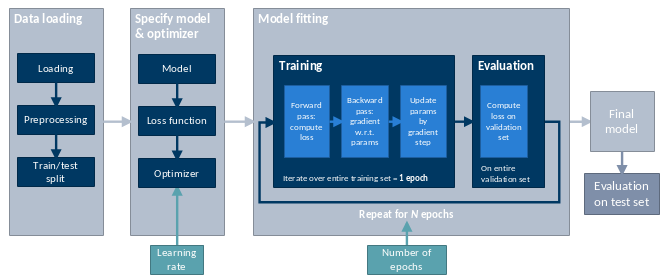

## Data Loading and Preprocessing

### Training, Validation and Test Sets

For the correct fitting of a machine learning model we need three dataset components: one for training, one for validation in the training process, and the last one for testing the results of the training on unseen data.

Note that you should not use the test set in any part of your training and model selection procedure. It should be only used for showing the final results.  

Usually, train and test datasets are already split in the provided kaggle datasets but as we work with a custom dataset, we would have to make train-test split ourselves first.

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
test_size = 0.2
target_clm='critical_temp'

In [41]:
# TODO: load data - same as in the previous practical and make train_test_split from sklearn

data = pd.read_csv("../data/superconduct_train.csv")
X = data.drop(columns=[target_clm])
y = data[target_clm]

train, test = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

### Dataset

PyTorch has 2 entities to load data. They are **Dataset** and **Dataloader**.
**Dataset** is a class, which defines your data and often applies data preprocessing transformations, like normalization. It should have at least 3 functions :
* __init__ - as any other init. Usually, you would provide path to dataset here or dataset elements.
* __len__ - should return the whole dataset size
* __getitem__ - this function returns 1 pair of data and label, also here preprocessing transformations are usually applied



For the next exercise, take a look here for an example https://stanford.edu/~shervine/blog/pytorch-how-to-generate-data-parallel

In [42]:
import torch
import numpy as np

class Dataset(torch.utils.data.Dataset):
    def __init__(self, df, target_clm, mean=None, std=None, normalise=True):
        """
        Save params, split features/target, convert to numpy,
        optionally store normalization stats.
        """

        self.normalise = normalise

        # split X and y
        self.x = df.drop(columns=[target_clm]).to_numpy(dtype="float32")
        self.y = df[target_clm].to_numpy(dtype="float32")

        # compute mean/std ONLY from training set if not provided
        self.mean = mean
        self.std = std

        if self.normalise: ## calculates both from data even if only one is none
            if self.mean is None or self.std is None:
                self.mean = self.x.mean(axis=0)
                self.std = self.x.std(axis=0) + 1e-8  # avoid division by zero 

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        x = self.x[index]
        y = self.y[index]

        # normalize if required
        if self.normalise:
            x = (x - self.mean) / self.std

        # convert to tensors
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [43]:
tmp_dataset = Dataset(train, target_clm, normalise=False)

In [44]:
# TODO calculate the mean and standard deviation of the train dataset
X_train = train.drop(columns=[target_clm])

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

In [45]:
# TODO define new datasets with mean, std and normalise=True
conductor_train = Dataset(train, target_clm, mean=mean, std=std, normalise=True)

conductor_test = Dataset(test, target_clm, mean=mean, std=std, normalise=True)

We need to **split** the train dataset in two sets, one for training and one for validation.
While the training set needs to be quite large, the validation set can be relatively small.
Take 10 % of the dataset as validation set.
Assign samples *randomly* to the training and validation set, using a fixed seed to ensure that train and test splits are same across different model runs.

In fact, the good practice is to fix a global random seed not only the generator seed for even better reproducibility with `torch.manual_seed(0)`.
Machine learning models often involve random initialization of weights, augmentations, dropout layers, and other stochastic processes. Without fixing the random seed, each run of the model may produce slightly different results, making it challenging to reproduce specific results or debug issues.

In [46]:
# TODO split the train dataset in conductor_train and conductor_val
torch.manual_seed(0)
from torch.utils.data import random_split
train_size = int(0.9 * len(conductor_train))
val_size = len(conductor_train) - train_size

conductor_train, conductor_val = random_split(
    conductor_train,
    [train_size, val_size]
)

In [47]:
batch_size = 256

To load the data for model training, we need to define the **dataloaders**.
A dataloader represents a Python iterable over a dataset and draws mini batches with random samples.
**Dataloader** calls \_\_getitem__ function from the Dataset and forms the batches.


Use the batch size as specified above.
Make sure we get shuffled samples in batches.

In [48]:
# TODO create dataloader for training, validation and test
from torch.utils.data import DataLoader

batch_size = 32  # use the one specified in your notebook ## TO DELETE

train_dataloader = DataLoader(
    conductor_train,
    batch_size=batch_size,
    shuffle=True
)

val_dataloader = DataLoader(
    conductor_val,
    batch_size=batch_size,
    shuffle=False
)

test_dataloader = DataLoader(
    conductor_test,
    batch_size=batch_size,
    shuffle=False
)

Let's get a data point now to see what we're dealing with.

For this, you might want to check out how python's iterator protocol works. It's simple and will give you an important insight into python: https://wiki.python.org/moin/Iterator.

In [49]:
# TODO get an element of the train_dataloader
data_iter = iter(train_dataloader)

# get one batch
x_batch, y_batch = next(data_iter)


C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


In [50]:
# TODO print the dimensions of for elements from the previous step
print("X batch shape:", x_batch.shape)
print("Y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 81])
Y batch shape: torch.Size([32])


x has size (\[batchsize\], 81) --> 256 elements/batches (or whatever you have defined in your data loader), 81 feature values.

y has size (\[batchsize\], 1) --> 256 elements/batches (again depends on your data loader config). There's one target value for each set of the features.

## Specify Model & Optimizer

### Specify a Model

The task is now to define a model to train on the data. In this simple example, we only need Linear Layer (often called a "fully-connected" layer in neural network contexts) as defined in *torch.nn.Linear* that produces a predicted label for a specific training input row.

Before, we set some variables:
- the input and output size of the linear layer
- how long we want to train the model (number of epochs) and
- the learning rate.


In [51]:
epochs = 1
input_dim = 81
output_dim = 1
lr = 0.001

In [52]:
import torch
import torch.nn as nn

class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim): 
        super().__init__()

        self.input_dim = input_dim
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = x.reshape(-1, self.input_dim) ## why ?
        return self.linear(x)

### Instantiate the Model

Let us instantiate the model and take a look at the inside. It is always a good idea to verify that the actual architecture is what you intended it to be. Especially, when you start to create layers dynamically it is great for inspection/verification/debugging.

In [53]:
# TODO instantiate the model
import torch.nn as nn
model = LinearRegression(input_dim=81, output_dim=1).float()

Feed the model to the GPU if available.

In [54]:
# TODO move model to device you specified above
model = model.to(device)

Put the model in training mode.

In [55]:
# TODO put the model in train mode
model.train()

LinearRegression(
  (linear): Linear(in_features=81, out_features=1, bias=True)
)

### Define a Loss Function

Since we're dealing with regression problem, [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) is the canonical choice for the loss.

In [56]:
# TODO define the loss function
import torch.nn as nn

loss_function = nn.MSELoss()

## Model Fitting

### Train the Model

Everything is set for the model to train!

- In the forward pass, the prediction is made using the previously defined model on the elements of the dataloader.
- Then the loss (or error) needs to be computed by comparing the prediction to the actual label.
- In the backward pass, the model learns and updates its weights based on the current gradient.

### First, let's do all of the steps manually, without using the optimizer

**Hints:**
* define number of epochs to see the dynamic. You need to see the effect over several epochs but it should no be too long.
* use learning rate defined above as `lr`
* when doing parameters update - do it under `with torch.no_grad():`. This would disable the gradient computation for the operations under it. And we don't need gradients for updating the weights step.
* you need to update the model parameters. See [here](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html) for more details on how to access them
* don't forget to track the learning (loss)
* even though you should not use a preimplemented optimizer here you are allowed to call `loss.backward()` to compute the individual gradients

In [57]:
# TODO do a simple for-loop to illustrate how the gradient update is done over batches.
# Print loss values across epochs to compare with the PyTorch optimizers later.

epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for x_batch, y_batch in train_dataloader:

        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float().reshape(-1, 1)

        # forward pass
        predictions = model(x_batch)

        # loss
        loss = loss_function(predictions, y_batch)

        # backward pass
        loss.backward()

        # manual gradient update
        with torch.no_grad(): # update weights without tracking gradients
            for param in model.parameters():
                param -= lr * param.grad # changes weights with formula new_weights = old_weights - learning_rate * gradient

        # clear gradients
        model.zero_grad()

        total_loss += loss.item() # total_loss := Sum of Loss over all batches

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1/5 - Loss: 493097.0004
Epoch 2/5 - Loss: 241035.8599
Epoch 3/5 - Loss: 198419.1246
Epoch 4/5 - Loss: 187343.6072
Epoch 5/5 - Loss: 182141.3145


This was equivalent to SGD optimizer

### Now let's do it in the pytorch style using the optimizer  

The optimizer is the learning algorithm we use. In this case, we use Stochastic Gradient Descent (SGD).
Redefine the model and initialize SGD optimizer

In [58]:
# TODO Redefine the model and initialize SGD optimizer, write a train loop as above and compare the loss values
import torch.optim as optim

# redefine model
model = LinearRegression(input_dim=81, output_dim=1).float().to(device)

# loss function
loss_function = torch.nn.MSELoss()

# SGD optimizer
optimizer = optim.SGD(model.parameters(), lr=lr)

# training loop
epochs = 15

for epoch in range(epochs):

    total_loss = 0

    for x_batch, y_batch in train_dataloader:

        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float().reshape(-1, 1)

        # clear old gradients
        optimizer.zero_grad()

        # forward pass
        predictions = model(x_batch)

        # compute loss
        loss = loss_function(predictions, y_batch)

        # backward pass
        loss.backward()

        # optimizer step
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1/15 - Loss: 495934.2439
Epoch 2/15 - Loss: 241466.2377
Epoch 3/15 - Loss: 198061.7208
Epoch 4/15 - Loss: 187158.3029
Epoch 5/15 - Loss: 181998.2519
Epoch 6/15 - Loss: 178677.7581
Epoch 7/15 - Loss: 176549.4829
Epoch 8/15 - Loss: 174622.2440
Epoch 9/15 - Loss: 173318.8311
Epoch 10/15 - Loss: 172159.4587
Epoch 11/15 - Loss: 171369.6782
Epoch 12/15 - Loss: 170323.8838
Epoch 13/15 - Loss: 169962.0790
Epoch 14/15 - Loss: 169154.1799
Epoch 15/15 - Loss: 168879.1897


### Make a Prediction

Now that our model is trained, we can make a new prediction by inputting an unseen data row from the test dataset.

Run this cell several times, does the model predict accurately?

Set the number of epochs to 15 during training and try again!

After running multiple times, the predictions vary slightly depending on the random sample.
With more epochs, the predictions become more accurate as the model has learned better weights. However, since this is a simple linear regression model, it cannot perfectly capture all patterns in the data.

In [59]:
# TODO get a random element of the test dataloader
import random
import torch

data_iter = iter(test_dataloader)

# convert dataloader to list of batches
test_batches = list(test_dataloader)

x_batch, y_batch = random.choice(test_batches)
idx = random.randint(0, x_batch.shape[0] - 1)

x_sample = x_batch[idx]
y_true = y_batch[idx]
# TODO make a prediction
model.eval()

with torch.no_grad():
    x_sample = x_sample.to(device).float()

    # add batch dimension
    x_sample = x_sample.unsqueeze(0)

    y_pred = model(x_sample)

# print predicted label and given label
print("Predicted value:", y_pred.item())
print("True value:", y_true.item())

C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Predicted value: 38.42515563964844
True value: 10.300000190734863


### Track and Plot the Training and Validation error

What we have seen so far is the basic principle of training a model and making a prediction. But one might be interesting to see more about the training process, for instance how the training error evolves with time.

For this step, we are going to **refine the training process** and **add some important information saving for plotting**.

Create a plot using **seaborn** that contains both the losses on training set and the losses on the validation set for each epoch.

The plot should look similar to this:


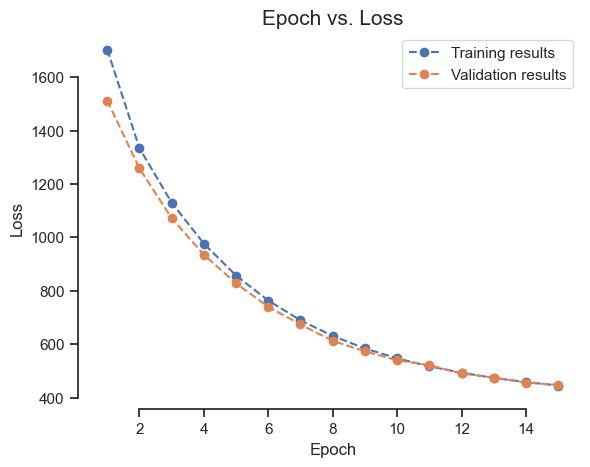


**Note:** Do not forget to add title, axis labels and a legend!
This applies in general, please keep in mind for future exercise sheets.

In [60]:
# TODO refine the training function from above
# it should contain:
# - saving of losses
# - returning the mean loss
def train_model(model, dataloader, loss_function, optimizer, device, epochs, lr):

    epoch_losses = []

    for epoch in range(epochs):
        model.train() ##

        batch_losses = []

        for x_batch, y_batch in dataloader:

            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float().reshape(-1, 1)

            # forward pass
            predictions = model(x_batch)

            # compute loss
            loss = loss_function(predictions, y_batch)

            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # save batch loss
            batch_losses.append(loss.item())

        # compute mean loss for epoch
        mean_loss = sum(batch_losses) / len(batch_losses)
        epoch_losses.append(mean_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {mean_loss:.4f}")

    return epoch_losses

In [61]:
# TODO write a validation function that calculates the loss on the validation set
# you can also combine it with the training function
def validate_model(model, dataloader, loss_function, device):

    model.eval()  # important: disables dropout/batchnorm behavior

    val_losses = []

    with torch.no_grad():  # no gradients needed

        for x_batch, y_batch in dataloader:

            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float().reshape(-1, 1)

            predictions = model(x_batch)

            loss = loss_function(predictions, y_batch)

            val_losses.append(loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)

    return mean_val_loss

In [62]:
# TODO write a run_training function that
# - calls the train and validate functions for each epoch
# - saves the train_losses, val_losses as arrays for each epoch
def run_training(model, train_dataloader, val_dataloader,
                 loss_function, optimizer, device, epochs):

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ---------------------
        # TRAINING PHASE
        # ---------------------
        model.train()
        batch_train_losses = []

        for x_batch, y_batch in train_dataloader:

            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float().reshape(-1, 1)

            optimizer.zero_grad()

            predictions = model(x_batch)
            loss = loss_function(predictions, y_batch)

            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        mean_train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(mean_train_loss)

        # ---------------------
        # VALIDATION PHASE
        # ---------------------
        model.eval()
        batch_val_losses = []

        with torch.no_grad():
            for x_batch, y_batch in val_dataloader:

                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).float().reshape(-1, 1)

                predictions = model(x_batch)
                loss = loss_function(predictions, y_batch)

                batch_val_losses.append(loss.item())

        mean_val_loss = sum(batch_val_losses) / len(batch_val_losses)
        val_losses.append(mean_val_loss)

        # ---------------------
        # LOGGING
        # ---------------------
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {mean_train_loss:.4f} | "
              f"Val Loss: {mean_val_loss:.4f}")

    return train_losses, val_losses

In [63]:
# TODO call the run_training function and run it for 10 epochs.
num_epochs = 15

train_losses, val_losses = run_training(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=num_epochs
)

C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1/15 | Train Loss: 351.0698 | Val Loss: 364.4251
Epoch 2/15 | Train Loss: 350.3357 | Val Loss: 362.2075
Epoch 3/15 | Train Loss: 349.1864 | Val Loss: 362.6183
Epoch 4/15 | Train Loss: 348.6479 | Val Loss: 362.6539
Epoch 5/15 | Train Loss: 348.0951 | Val Loss: 360.3570
Epoch 6/15 | Train Loss: 347.0998 | Val Loss: 359.5814
Epoch 7/15 | Train Loss: 346.6733 | Val Loss: 359.4352
Epoch 8/15 | Train Loss: 346.1384 | Val Loss: 358.9434
Epoch 9/15 | Train Loss: 345.7027 | Val Loss: 358.9197
Epoch 10/15 | Train Loss: 344.9458 | Val Loss: 360.4669
Epoch 11/15 | Train Loss: 344.5037 | Val Loss: 358.3851
Epoch 12/15 | Train Loss: 343.7994 | Val Loss: 358.0001
Epoch 13/15 | Train Loss: 343.5551 | Val Loss: 358.2439
Epoch 14/15 | Train Loss: 343.1843 | Val Loss: 356.3209
Epoch 15/15 | Train Loss: 342.8972 | Val Loss: 355.5852


In [2]:
# TODO write a plot function
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 5))

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

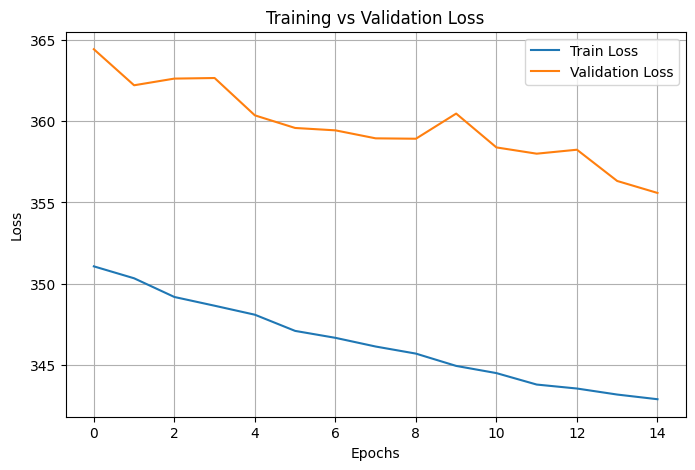

In [65]:
# TODO plot losses
plot_losses(train_losses, val_losses)

Comment on the loss curve. Does it look as expected? Why/Why not?
If not, what might be the reason.


The training loss decreases slowly, which is expected for a simple linear regression model trained with SGD. The validation loss fluctuates across epochs, which is likely due to the stochastic nature of batch training, the limited model capacity, and noise in the dataset. Overall, the model is learning but has limited ability to fully capture the complexity of the data.

# Hyperparameters influence

Now, once we successfully reproduced linear regression using PyTorch, lets explore the hyperparameters influence, such as learning rate or batch size.

Train several models with 30 train epochs and using different learning rates - [0.0001, 0.001, 0.01, 0.1, 1, 10].
What do you notice? Why?

*Hints*:
* Do not forget to reinitialize models and update the optimizers
* Use different colors and line styles to display different learning rates and train-validation splits

In [66]:
num_epochs = 30
## TODO - train models with different learning rates
import copy

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1, 10]

results = {}

num_epochs = 30

for lr in learning_rates:

    print(f"\nTraining model with lr = {lr}")

    # reinitialize model (IMPORTANT)
    model = LinearRegression(input_dim=81, output_dim=1).float().to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = run_training(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        loss_function=loss_function,
        optimizer=optimizer,
        device=device,
        epochs=num_epochs
    )

    results[lr] = {
        "train": train_losses,
        "val": val_losses
    }


Training model with lr = 0.0001


C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1/30 | Train Loss: 1784.9557 | Val Loss: 1459.0268
Epoch 2/30 | Train Loss: 1436.1477 | Val Loss: 1259.4609
Epoch 3/30 | Train Loss: 1247.0191 | Val Loss: 1106.2844
Epoch 4/30 | Train Loss: 1100.6757 | Val Loss: 984.2021
Epoch 5/30 | Train Loss: 981.9833 | Val Loss: 884.5730
Epoch 6/30 | Train Loss: 884.5394 | Val Loss: 801.9932
Epoch 7/30 | Train Loss: 804.6138 | Val Loss: 735.5306
Epoch 8/30 | Train Loss: 737.7966 | Val Loss: 678.5216
Epoch 9/30 | Train Loss: 683.1440 | Val Loss: 632.1701
Epoch 10/30 | Train Loss: 637.4719 | Val Loss: 593.9388
Epoch 11/30 | Train Loss: 599.4233 | Val Loss: 562.2655
Epoch 12/30 | Train Loss: 567.3093 | Val Loss: 535.3153
Epoch 13/30 | Train Loss: 541.2582 | Val Loss: 513.1780
Epoch 14/30 | Train Loss: 518.7579 | Val Loss: 495.6601
Epoch 15/30 | Train Loss: 500.0309 | Val Loss: 479.5111
Epoch 16/30 | Train Loss: 483.9660 | Val Loss: 466.7497
Epoch 17/30 | Train Loss: 470.6788 | Val Loss: 455.9276
Epoch 18/30 | Train Loss: 459.3617 | Val Loss: 447

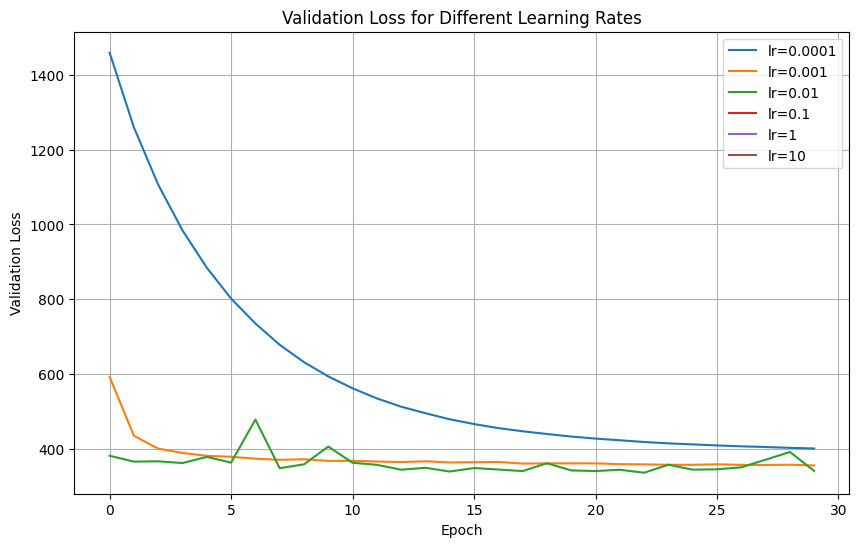

In [67]:
## TODO plot the losses from different models. What do you see and why?
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(results[lr]["val"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

## How do we know the amount of epochs and best learning rates?

The honest answer - we just try it out. The heuristics, which are typically used are the following
* use adaptive optimizers. Adam would be a typical example. It is an adaptive learning rate optimization algorithm that is designed to be appropriate for non-stationary objectives and problems with very noisy and/or sparse gradients. More details [here](https://paperswithcode.com/method/adam). This makes the training more robust to the choise of the the learning rate
* Use schedulers for the training. They change the value of the learning rate based on the loss behaviour. The most typical ones are
  * Early stopper . The early stopper is helpful to avoid redundunt computations and overfitting. It basically stops the train loop if the loss function does not decrease on the validation split for some time.
  * Warm up. Warm up slowly increases the learning rate in the begining of the training. This helps to avoid bad influence of not-so-good initialisation and especially helpful for the layers, which need to accumulate statistics, such as BatchNorm. We will use such layers later in the course.

### Task
Modify the the training function with the early stopper logic.
This should stop the training loop if the validation loss function does not have a relevant improvement over $N$ epochs. The improvement is only something, which is better than the $tol$ value, which stays for the tolerance.

Use $tol=2$, $N=5$, $num\_epochs=150$, $lr=0.01$ for the function start.

**Question**:
* Can $tol=0$? Why?
* How many epochs it would really run? Try to change the $lr=0.001$ and $lr=0.0001$ and see when this would stop.
* What happens if you increase the tolerance?
* What if you increase $N$?

-Yes tol = 0 is possible, but not practical. Validation loss is noisy, so tiny fluctuations would constantly affect the stopping condition, making early stopping unstable or unreliable.

-The number of epochs depends on the learning rate. With lr = 0.001, training converges reasonably fast and typically stops early (well before 150 epochs). With lr = 0.0001, learning is much slower, so the model may run many more epochs or stop very late due to very small improvements.

-Increasing tol makes early stopping more strict, so training stops earlier because small improvements are ignored, which can lead to underfitting.

-Increasing N (patience) allows more epochs without improvement before stopping, making training longer but more stable against fluctuations.

In [68]:
## TODO: adopt the train function with the early stopper logic
def run_training_early_stopping(model, train_dataloader, val_dataloader,
                                loss_function, optimizer, device,
                                num_epochs=150, tol=2, N=5):

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    no_improve_counter = 0

    for epoch in range(num_epochs):

        # ---------------- TRAIN ----------------
        model.train()
        batch_train_losses = []

        for x_batch, y_batch in train_dataloader:

            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float().reshape(-1, 1)

            optimizer.zero_grad()

            predictions = model(x_batch)
            loss = loss_function(predictions, y_batch)

            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        # ---------------- VALIDATION ----------------
        model.eval()
        batch_val_losses = []

        with torch.no_grad():
            for x_batch, y_batch in val_dataloader:

                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).float().reshape(-1, 1)

                predictions = model(x_batch)
                loss = loss_function(predictions, y_batch)

                batch_val_losses.append(loss.item())

        val_loss = sum(batch_val_losses) / len(batch_val_losses)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        # ---------------- EARLY STOPPING ----------------
        improvement = best_val_loss - val_loss

        if improvement > tol:
            best_val_loss = val_loss
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        if no_improve_counter >= N:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return train_losses, val_losses


In [69]:
## TODO: Train models with early stopping with the different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

num_epochs = 150
tol = 2
N = 5

results = {}

for lr in learning_rates:

    print(f"\nTraining with lr = {lr}")

    # reinitialize model EACH time
    model = LinearRegression(input_dim=81, output_dim=1).float().to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = run_training_early_stopping(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        loss_function=loss_function,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        tol=tol,
        N=N
    )

    results[lr] = {
        "train": train_losses,
        "val": val_losses
    }


Training with lr = 0.0001


C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1 | Train: 1786.3395 | Val: 1454.3735
Epoch 2 | Train: 1433.0600 | Val: 1255.1147
Epoch 3 | Train: 1243.6407 | Val: 1102.0810
Epoch 4 | Train: 1096.2500 | Val: 980.8857
Epoch 5 | Train: 978.7428 | Val: 881.3701
Epoch 6 | Train: 881.7286 | Val: 799.6382
Epoch 7 | Train: 802.1691 | Val: 731.6145
Epoch 8 | Train: 736.0186 | Val: 676.0437
Epoch 9 | Train: 681.5215 | Val: 629.7433
Epoch 10 | Train: 635.7788 | Val: 591.2080
Epoch 11 | Train: 598.0736 | Val: 560.4516
Epoch 12 | Train: 566.2988 | Val: 533.9535
Epoch 13 | Train: 539.6726 | Val: 512.1855
Epoch 14 | Train: 518.2251 | Val: 494.0308
Epoch 15 | Train: 498.9063 | Val: 479.3372
Epoch 16 | Train: 482.9603 | Val: 465.9516
Epoch 17 | Train: 469.6110 | Val: 455.7090
Epoch 18 | Train: 458.2612 | Val: 447.0837
Epoch 19 | Train: 449.1410 | Val: 439.2992
Epoch 20 | Train: 440.3698 | Val: 432.3437
Epoch 21 | Train: 433.6976 | Val: 426.7037
Epoch 22 | Train: 427.3393 | Val: 422.1101
Epoch 23 | Train: 421.9968 | Val: 418.8650
Epoch 24 | Tr

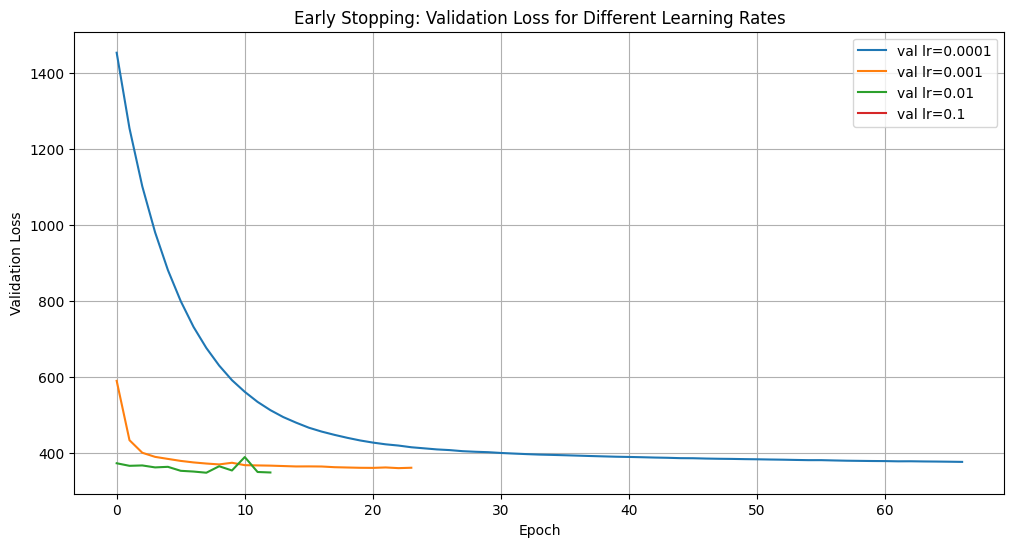

In [70]:
## TODO: Visualize the results. What do you see and why?
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    plt.plot(results[lr]["val"], label=f"val lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Early Stopping: Validation Loss for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()


## Now lets try to explore the impact of the batch size

**Task:** Fix $num\_epochs = 150$ and $lr = 0.001$ and try to change the batch size using values $[4, 32, 128, 1024]$ for the batch size.
* What impact the batch size have? Why?

Batch size affects the stability and quality of training.
Small batch sizes (e.g. 4) make training noisy because updates are based on few samples, but can improve generalization. Medium sizes (32, 128) usually give the best balance between stability and performance. Large batch sizes (1024) make training smoother but slower in learning progress and may reduce generalization because updates are less frequent and less noisy.

In [71]:
num_epochs = 150
lr = 0.001
## TODO: Train with different batch sizes
import copy

batch_sizes = [4, 32, 128, 1024]

num_epochs = 150
lr = 0.001
tol = 2
N = 5

results_bs = {}

for bs in batch_sizes:

    print(f"\nTraining with batch size = {bs}")

    # re-create dataloaders with new batch size
    train_loader = DataLoader(conductor_train, batch_size=bs, shuffle=True)
    val_loader = DataLoader(conductor_val, batch_size=bs, shuffle=False)

    # reinitialize model
    model = LinearRegression(input_dim=81, output_dim=1).float().to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = run_training_early_stopping(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        loss_function=loss_function,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        tol=tol,
        N=N
    )

    results_bs[bs] = {
        "train": train_losses,
        "val": val_losses
    }


Training with batch size = 4


C:\Users\wgast\AppData\Local\Temp\ipykernel_6500\1144099915.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1 | Train: 486.3276 | Val: 385.7733
Epoch 2 | Train: 360.5384 | Val: 372.0986
Epoch 3 | Train: 353.3091 | Val: 369.7341
Epoch 4 | Train: 348.5473 | Val: 371.2780
Epoch 5 | Train: 344.1543 | Val: 360.8977
Epoch 6 | Train: 342.4123 | Val: 359.8412
Epoch 7 | Train: 340.0003 | Val: 355.3279
Epoch 8 | Train: 337.8546 | Val: 359.6029
Epoch 9 | Train: 336.7093 | Val: 356.8871
Epoch 10 | Train: 335.1331 | Val: 366.6365
Epoch 11 | Train: 333.9595 | Val: 357.5209
Epoch 12 | Train: 332.8186 | Val: 353.5122
Early stopping at epoch 12

Training with batch size = 32
Epoch 1 | Train: 1033.4562 | Val: 595.2139
Epoch 2 | Train: 504.4378 | Val: 432.2649
Epoch 3 | Train: 415.3322 | Val: 403.1942
Epoch 4 | Train: 390.9851 | Val: 392.5448
Epoch 5 | Train: 380.5921 | Val: 383.1241
Epoch 6 | Train: 373.4939 | Val: 379.0859
Epoch 7 | Train: 368.4982 | Val: 375.9974
Epoch 8 | Train: 364.8384 | Val: 373.0467
Epoch 9 | Train: 362.1198 | Val: 374.4901
Epoch 10 | Train: 359.5605 | Val: 371.4956
Epoch 11 | Tr

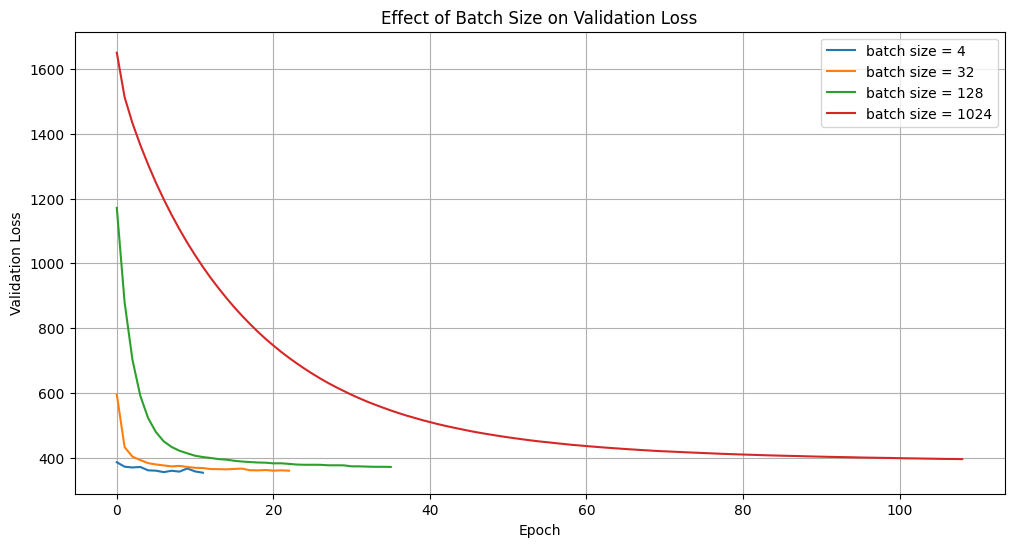

In [72]:
## TODO: Visualize the differences
plt.figure(figsize=(12, 6))

for bs in batch_sizes:
    plt.plot(results_bs[bs]["val"], label=f"batch size = {bs}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Batch Size on Validation Loss")
plt.legend()
plt.grid()
plt.show()